<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_66_adaboost_Practical_Code_demo/Lecture_66_adaboost_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
# Create an empty pandas DataFrame
df = pd.DataFrame()

In [3]:
# Add data to the DataFrame
df['X1'] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 9 ]
df['X2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2 ]
df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

In [4]:
# Display the DataFrame
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,7,5,0
7,8,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

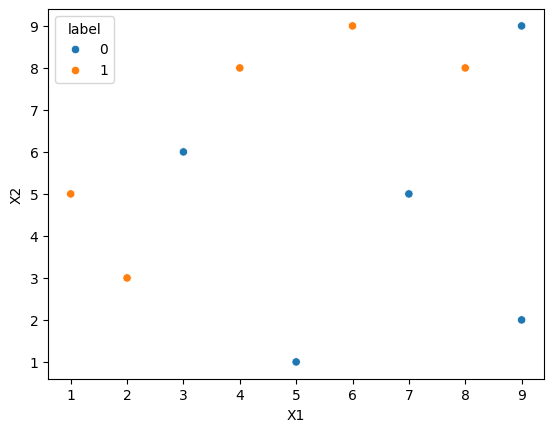

In [5]:
# Import seaborn for plotting
import seaborn as sns
# Create a scatter plot of X1 vs X2, colored by label
sns.scatterplot(data=df, x='X1', y='X2', hue='label')

In [6]:
# Initialize weights for each data point
df['weights'] = 1/df.shape[0]

In [7]:
# Display the DataFrame with weights
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

In [15]:
# Create a Decision Tree Classifier with max_depth=1
dt1 = DecisionTreeClassifier(max_depth=1)

In [16]:
# Separate features (X) and target (y)
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [17]:
# Fit the first Decision Tree model
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

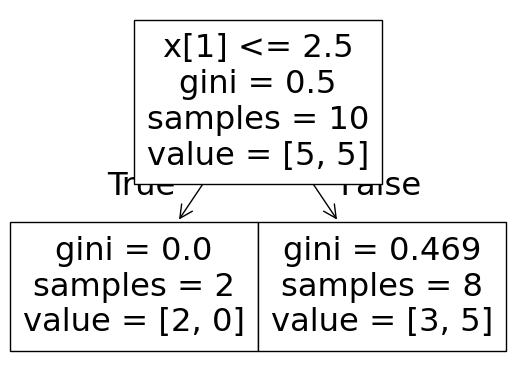

In [18]:
# Plot the decision tree
from  sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

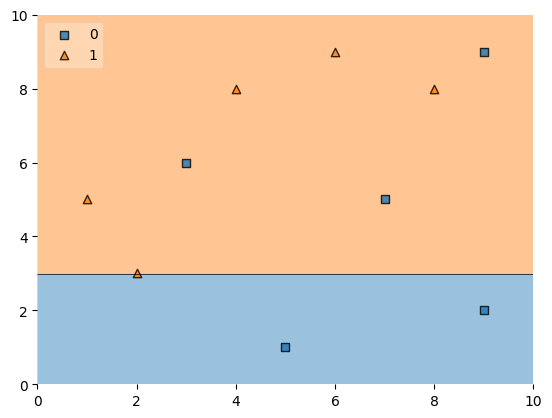

In [19]:
# Plot the decision boundary of the first model
plot_decision_regions(X, y, clf=dt1, legend=2)

In [20]:
# Predict the labels using the first model
df['y_pred'] = dt1.predict(X)

In [21]:
# Display the DataFrame with predictions
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,7,5,0,0.1,1
7,8,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [22]:
# Define a function to calculate the model weight (alpha)
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error)

In [23]:
# Calculate the weight for the first model
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [24]:
# Define a function to update row weights based on prediction correctness
def update_row_weights(row, alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [25]:
# Apply the update_row_weights function to calculate updated weights
df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [26]:
# Display the DataFrame with updated weights
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,7,5,0,0.1,1,0.152653
7,8,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [28]:
# Calculate the sum of updated weights
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [27]:
# Normalize the updated weights
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [29]:
# Display the DataFrame with normalized weights
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,7,5,0,0.1,1,0.152653,0.166559
7,8,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [32]:
# Calculate the sum of normalized weights (should be close to 1)
df['normalized_weights'].sum()

np.float64(1.0)

In [33]:
# Calculate the cumulative sum of normalized weights (upper bound)
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [34]:
# Calculate the cumulative sum of normalized weights (lower bound)
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [35]:
# Display selected columns of the DataFrame
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,7,5,0,0.1,1,0.152653,0.523933,0.690492
7,8,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [39]:
# Define a function to create a new dataset by sampling with replacement based on weights
def create_new_dataset(df):
  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index, row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)

  return indices

In [40]:
# Create a new dataset by sampling from the original DataFrame based on normalized weights
index_values = create_new_dataset(df)
index_values

[2, 0, 5, 0, 1, 1, 1, 6, 6, 6]

In [41]:
# Create the second DataFrame using the sampled indices
second_df = df.iloc[index_values,[0, 1, 2, 3]]

In [42]:
# Display the second DataFrame
second_df

,X1,X2,label,weights
2,3,6,0,0.1
0,1,5,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
6,7,5,0,0.1
6,7,5,0,0.1
6,7,5,0,0.1


In [44]:
# Create the second Decision Tree Classifier with max_depth=1
dt2 = DecisionTreeClassifier(max_depth=1)

In [45]:
# Separate features (x) and target (y) for the second dataset
x = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [46]:
# Fit the second Decision Tree model
dt2.fit(x, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.625, 0.5, '  False')]

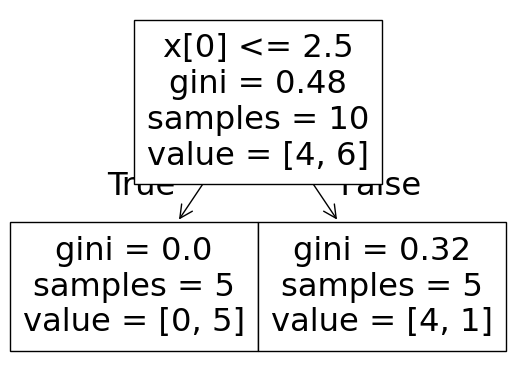

In [47]:
# Plot the second decision tree
plot_tree(dt2)

<Axes: >

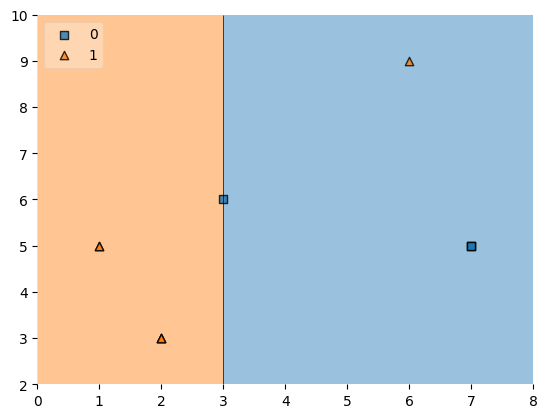

In [48]:
# Plot the decision boundary of the second model
plot_decision_regions(x, y, clf=dt2, legend=2)

In [49]:
# Predict the labels using the second model
second_df['y_pred'] = dt2.predict(x)

In [50]:
# Display the second DataFrame with predictions
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
0,1,5,1,0.1,1
5,6,9,1,0.1,0
0,1,5,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
6,7,5,0,0.1,0
6,7,5,0,0.1,0
6,7,5,0,0.1,0


In [53]:
# Calculate the weight for the second model
alpha2 = calculate_model_weight(0.1)

In [54]:
# Display the weight for the second model
alpha2

np.float64(1.0986122886681098)

In [56]:
# Define a function to update row weights based on prediction correctness (redefined for clarity, could reuse the previous one)
def update_row_weights(row, alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [57]:
# Apply the update_row_weights function to calculate updated weights for the second DataFrame
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)

In [58]:
# Display the second DataFrame with updated weights
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
0,1,5,1,0.1,1,0.033622
5,6,9,1,0.1,0,0.297427
0,1,5,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
6,7,5,0,0.1,0,0.033622
6,7,5,0,0.1,0,0.033622
6,7,5,0,0.1,0,0.033622


In [60]:
# Calculate the sum of updated weights for the second DataFrame
second_df['updated_weights'].sum()

np.float64(0.6000222515923667)

In [61]:
# Normalize the updated weights for the second DataFrame
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [62]:
# Display the second DataFrame with normalized weights
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
2,3,6,0,0.1,0,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,0,0.297427,0.495694
0,1,5,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
6,7,5,0,0.1,0,0.033622,0.056034
6,7,5,0,0.1,0,0.033622,0.056034
6,7,5,0,0.1,0,0.033622,0.056034


In [63]:
# Calculate the sum of normalized weights for the second DataFrame (should be close to 1)
second_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [65]:
# Calculate the cumulative sum of normalized weights (upper bound) for the second DataFrame
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [66]:
# Calculate the cumulative sum of normalized weights (lower bound) for the second DataFrame
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [67]:
# Display selected columns of the second DataFrame
second_df[['X1','X2','label','weights','y_pred','normalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.056034,0.000000,0.056034
0,1,5,1,0.1,1,0.056034,0.056034,0.112068
5,6,9,1,0.1,0,0.495694,0.112068,0.607762
0,1,5,1,0.1,1,0.056034,0.607762,0.663796
1,2,3,1,0.1,1,0.056034,0.663796,0.719830
1,2,3,1,0.1,1,0.056034,0.719830,0.775864
1,2,3,1,0.1,1,0.056034,0.775864,0.831898
6,7,5,0,0.1,0,0.056034,0.831898,0.887932
6,7,5,0,0.1,0,0.056034,0.887932,0.943966
6,7,5,0,0.1,0,0.056034,0.943966,1.000000


In [68]:
# Create the third dataset by sampling from the second DataFrame based on normalized weights
index_values = create_new_dataset(second_df)

In [69]:
# Create the third DataFrame using the sampled indices
third_df = second_df.iloc[index_values,[0, 1, 2, 3]]

In [70]:
# Display the third DataFrame
third_df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
0,1,5,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1


In [71]:
# Create the third Decision Tree Classifier with max_depth=1
dt3 = DecisionTreeClassifier(max_depth=1)

In [77]:
# Separate features (X) and target (y) for the third dataset (using data from second_df)
X  = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [79]:
# Fit the third Decision Tree model
dt3.fit(X, y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

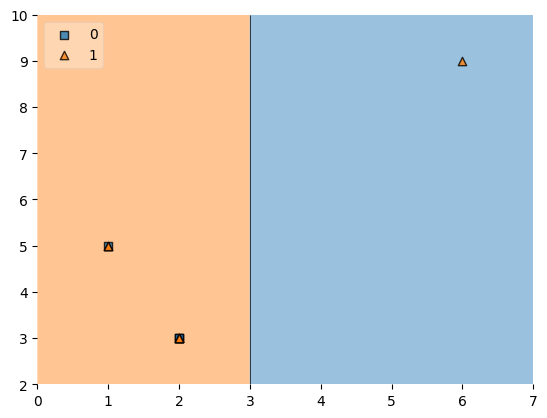

In [80]:
# Plot the decision boundary of the third model
plot_decision_regions(x, y, clf=dt3, legend=2)

In [81]:
# Predict the labels using the third model
third_df['y_pred'] = dt3.predict(X)

In [82]:
# Display the third DataFrame with predictions
third_df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,0
1,2,3,1,0.1,1
5,6,9,1,0.1,0
0,1,5,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
0,1,5,1,0.1,1
1,2,3,1,0.1,0
1,2,3,1,0.1,0
1,2,3,1,0.1,0


In [85]:
# Calculate the weight for the third model
alpha3 = calculate_model_weight(0.7)

In [86]:
# Display the weight for the third model
alpha3

np.float64(-0.4236489301936017)

In [87]:
# Print the weights of the three models
print(alpha1,alpha2, alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


# prediction

In [88]:
# Define a query point and predict its label using the first model
query = np.array([1, 5]).reshape(1,2)
dt1.predict(query)

array([1])

In [89]:
# Predict the label of the query point using the second model
dt2.predict(query)

array([1])

In [90]:
# Predict the label of the query point using the third model
dt3.predict(query)

array([1])

In [92]:
# Calculate the weighted sum of predictions for the first query point
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [93]:
# Determine the final prediction for the first query point using the sign of the weighted sum
np.sign(1.09)

np.float64(1.0)

**second points**

In [97]:
# Define a second query point and predict its label using the first model
query = np.array([9, 9]).reshape(1,2)
dt1.predict(query)

array([1])

In [98]:
# Predict the label of the second query point using the second model
dt2.predict(query)

array([0])

In [99]:
# Predict the label of the second query point using the third model
dt3.predict(query)

array([0])

In [100]:
# Calculate the weighted sum of predictions for the second query point
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [101]:
# Determine the final prediction for the second query point using the sign of the weighted sum
np.sign(-0.25)

np.float64(-1.0)